# GrabFood Fraud Analytics: Deteksi Kebocoran Subsidi GrabUnlimited

**Role:** Data Analyst – GrabFood / Fraud Analytics  
**Objective:**
membantu stakeholder mengidentifikasi kebocoran subsidi promo, kualitas data operasional, dan prioritas investigasi merchant yang berpotensi menyalahgunakan program GrabUnlimited.

## 1. Business Understanding

GrabUnlimited memberikan subsidi berupa diskon dan gratis ongkir untuk meningkatkan retensi pelanggan. Namun, program seperti ini dapat dieksploitasi apabila merchant, user, atau driver bekerja sama untuk membuat transaksi fiktif. Risiko bisnis utama pada kasus ini adalah:

1. kebocoran subsidi promo;
2. peningkatan cancellation rate yang merugikan driver organik;
3. data operasional yang kotor sehingga menyulitkan investigasi;
4. adanya bug atau logical error pada alur status order.

### Pertanyaan Analisis

1. Apakah terdapat merchant dengan rasio transaksi sukses tinggi, tetapi pembelinya hanya berasal dari 2–3 akun user yang sama?
2. Berapa estimasi subsidi promo yang berisiko bocor akibat transaksi tidak wajar?
3. Seberapa kotor dan tidak konsisten status pesanan serta cancel reason?
4. Berapa persentase order batal/gagal yang tidak memiliki cancel reason?
5. Berapa banyak order berstatus selesai tetapi `completed_time` terjadi sebelum `driver_arrived_time`?
6. Cuisine type dan merchant mana yang paling perlu diprioritaskan untuk investigasi?

## 2. Import Library dan Load Data

Notebook ini menggunakan `pandas` dan `numpy` untuk data manipulation, `matplotlib`/`seaborn` untuk visualisasi, serta pendekatan rule-based anomaly detection sesuai konteks bisnis.

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 200)
pd.set_option('display.max_colwidth', 120)

# Agar notebook dapat dijalankan baik di folder lokal maupun environment /mnt/data
DATA_DIR = Path('.')
if not (DATA_DIR / 'grab_food_orders.csv').exists():
    DATA_DIR = Path('dataset_grab')

orders = pd.read_csv(DATA_DIR / 'grab_food_orders.csv')
merchants = pd.read_csv(DATA_DIR / 'grab_merchants.csv')
users = pd.read_csv(DATA_DIR / 'grab_users.csv')

print('Shape orders:', orders.shape)
print('Shape merchants:', merchants.shape)
print('Shape users:', users.shape)

Shape orders: (300000, 9)
Shape merchants: (8000, 4)
Shape users: (40000, 3)


In [48]:
display(orders.head())
display(merchants.head())
display(users.head())

,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaN
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaN
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00


,merchant_id,merchant_name,cuisine_type,city
0,GF-00001,Resto GrabMantap 0,Seafood,Depok
1,GF-00002,Resto GrabMantap 1,Fast Food,Surabaya
2,GF-00003,Resto GrabMantap 2,Martabak,Tangerang
3,GF-00004,Resto GrabMantap 3,Martabak,Jakarta
4,GF-00005,Resto GrabMantap 4,Snacks,Bekasi


,user_id,is_grab_unlimited,account_age_days
0,GB-000001,False,91
1,GB-000002,False,1048
2,GB-000003,True,985
3,GB-000004,True,1357
4,GB-000005,False,16


## 3. Data Understanding

Tahap ini mengecek struktur data, tipe data, duplikasi, missing value, dan konsistensi key antar tabel.

In [49]:
# Informasi dataset
print('Orders info:')
orders.info()
print('\nMerchants info:')
merchants.info()
print('\nUsers info:')
users.info()

Orders info:
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   order_id             300000 non-null  str  
 1   merchant_id          300000 non-null  str  
 2   user_id              300000 non-null  str  
 3   order_status         300000 non-null  str  
 4   promo_discount       300000 non-null  int64
 5   cancel_reason        35780 non-null   str  
 6   order_time           300000 non-null  str  
 7   driver_arrived_time  270320 non-null  str  
 8   completed_time       240093 non-null  str  
dtypes: int64(1), str(8)
memory usage: 20.6 MB

Merchants info:
<class 'pandas.DataFrame'>
RangeIndex: 8000 entries, 0 to 7999
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   merchant_id    8000 non-null   str  
 1   merchant_name  8000 non-null   str  
 2   cuisine_type   80

In [50]:
# Ringkasan unique values
summary_unique = []
for name, data in [('orders', orders), ('merchants', merchants), ('users', users)]:
    for col in data.columns:
        summary_unique.append({
            'table': name,
            'column': col,
            'dtype': str(data[col].dtype),
            'n_unique': data[col].nunique(dropna=True),
            'missing': data[col].isna().sum(),
            'missing_pct': data[col].isna().mean()
        })
summary_unique = pd.DataFrame(summary_unique)
display(summary_unique)

,table,column,dtype,n_unique,missing,missing_pct
0,orders,order_id,str,300000,0,0.000000
1,orders,merchant_id,str,8000,0,0.000000
2,orders,user_id,str,39978,0,0.000000
3,orders,order_status,str,7,0,0.000000
4,orders,promo_discount,int64,7,0,0.000000
5,orders,cancel_reason,str,4,264220,0.880733
6,orders,order_time,str,129984,0,0.000000
7,orders,driver_arrived_time,str,127363,29680,0.098933
8,orders,completed_time,str,122206,59907,0.199690
9,merchants,merchant_id,str,8000,0,0.000000


In [51]:
# Duplikasi dan integritas key
quality_check = pd.DataFrame({
    'check': [
        'duplicate order_id',
        'duplicate merchant_id',
        'duplicate user_id',
        'orders merchant_id not found',
        'orders user_id not found'
    ],
    'value': [
        orders['order_id'].duplicated().sum(),
        merchants['merchant_id'].duplicated().sum(),
        users['user_id'].duplicated().sum(),
        (~orders['merchant_id'].isin(merchants['merchant_id'])).sum(),
        (~orders['user_id'].isin(users['user_id'])).sum()
    ]
})
display(quality_check)

,check,value
0,duplicate order_id,0
1,duplicate merchant_id,0
2,duplicate user_id,0
3,orders merchant_id not found,0
4,orders user_id not found,0


In [52]:
# Mengecek distribusi promo_discount
orders['promo_discount'].describe()

count    3.000000e+05
mean     6.035158e+04
std      7.018429e+05
min     -5.000000e+03
25%      0.000000e+00
50%      1.000000e+04
75%      2.000000e+04
max      9.999999e+06
Name: promo_discount, dtype: float64

In [53]:
orders['promo_discount'].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99, 0.995, 0.999]
)

count    3.000000e+05
mean     6.035158e+04
std      7.018429e+05
min     -5.000000e+03
25%      0.000000e+00
50%      1.000000e+04
75%      2.000000e+04
90%      3.000000e+04
95%      3.000000e+04
99%      3.000000e+04
99.5%    3.000000e+04
99.9%    9.999999e+06
max      9.999999e+06
Name: promo_discount, dtype: float64

**Catatan awal:** tidak ditemukan duplikasi ID maupun foreign key yang tidak cocok. Masalah utama justru terdapat pada inkonsistensi label status, missing value pada `cancel_reason`, dan anomali numerik pada `promo_discount`.

## 4. Data Cleaning dan Feature Engineering

Cleaning yang dilakukan:

1. Standarisasi `order_status` menjadi `Completed`, `Canceled`, dan `Failed`.
2. Konversi kolom waktu menjadi `datetime`.
3. Membuat flag transaksi sukses/batal/gagal.
4. Membuat flag logical error ketika `completed_time < driver_arrived_time`.
5. Membuat flag promo outlier dengan rule `promo_discount > 30000`.
6. Menyimpan nilai negatif promo sebagai anomali, tetapi menghitung estimasi subsidi menggunakan `positive_promo = max(promo_discount, 0)`.

In [54]:
orders_clean = orders.copy()

status_map = {
    'Completed': 'Completed',
    'Selesai': 'Completed',
    'DONE': 'Completed',
    'Cancel': 'Canceled',
    'CANCELED': 'Canceled',
    'batal': 'Canceled',
    'Failed': 'Failed'
}
orders_clean['status_clean'] = orders_clean['order_status'].map(status_map)

for col in ['order_time', 'driver_arrived_time', 'completed_time']:
    orders_clean[col] = pd.to_datetime(orders_clean[col], errors='coerce')

orders_clean['is_success'] = orders_clean['status_clean'].eq('Completed')
orders_clean['is_cancel'] = orders_clean['status_clean'].eq('Canceled')
orders_clean['is_failed'] = orders_clean['status_clean'].eq('Failed')
orders_clean['logical_error'] = (
    orders_clean['is_success'] &
    orders_clean['completed_time'].notna() &
    orders_clean['driver_arrived_time'].notna() &
    (orders_clean['completed_time'] < orders_clean['driver_arrived_time'])
)
orders_clean['discount_outlier'] = orders_clean['promo_discount'] > 30000
orders_clean['negative_discount'] = orders_clean['promo_discount'] < 0
orders_clean['positive_promo'] = orders_clean['promo_discount'].clip(lower=0)
orders_clean['subsidy_risk_flag'] = orders_clean['discount_outlier'] | orders_clean['logical_error']
orders_clean['date'] = orders_clean['order_time'].dt.date
orders_clean['order_month'] = orders_clean['order_time'].dt.to_period('M').astype(str)

df = orders_clean.merge(merchants, on='merchant_id', how='left').merge(users, on='user_id', how='left')

display(df.head())


,order_id,merchant_id,user_id,order_status,promo_discount,cancel_reason,order_time,driver_arrived_time,completed_time,status_clean,is_success,is_cancel,is_failed,logical_error,discount_outlier,negative_discount,positive_promo,subsidy_risk_flag,date,order_month,merchant_name,cuisine_type,city,is_grab_unlimited,account_age_days
0,GF-ORD-00000001,GF-06555,GB-019659,Completed,0,NaN,2023-12-21 09:43:00,2023-12-21 10:00:00,2023-12-21 10:16:00,Completed,True,False,False,False,False,False,0,False,2023-12-21,2023-12,Resto GrabMantap 6554,Fast Food,Bandung,False,1363
1,GF-ORD-00000002,GF-07698,GB-019520,Cancel,0,Resto Tidak Ditemukan,2023-12-20 14:01:00,2023-12-20 14:13:00,NaT,Canceled,False,True,False,False,False,False,0,False,2023-12-20,2023-12,Resto GrabMantap 7697,Ayam Geprek,Medan,True,472
2,GF-ORD-00000003,GF-02054,GB-030006,CANCELED,15000,Menu Habis,2024-02-18 12:56:00,2024-02-18 13:06:00,NaT,Canceled,False,True,False,False,False,False,15000,False,2024-02-18,2024-02,Resto GrabMantap 2053,Fast Food,Bandung,True,1226
3,GF-ORD-00000004,GF-05867,GB-021929,Completed,30000,NaN,2023-12-21 16:12:00,2023-12-21 16:24:00,2023-12-21 16:58:00,Completed,True,False,False,False,False,False,30000,False,2023-12-21,2023-12,Resto GrabMantap 5866,Martabak,Bogor,True,604
4,GF-ORD-00000005,GF-06915,GB-008802,DONE,0,NaN,2024-02-03 09:13:00,2024-02-03 09:20:00,2024-02-03 09:36:00,Completed,True,False,False,False,False,False,0,False,2024-02-03,2024-02,Resto GrabMantap 6914,Fast Food,Medan,False,1479


In [55]:
# Cek perubahan status sumber VS status yg sudah cleaning
status_mapping_table = pd.crosstab(df['order_status'], df['status_clean'])
display(status_mapping_table)

print('Jumlah status sumber:', df['order_status'].nunique())
print('Jumlah status setelah standardisasi:', df['status_clean'].nunique())
print('Baris dengan label status tidak standar:', (~df['order_status'].isin(['Completed','Cancel','Failed'])).sum())
print('Baris dengan label status standar:', (df['order_status'].isin(['Completed','Cancel','Failed'])).sum())

status_clean,Canceled,Completed,Failed
order_status,,,
CANCELED,14984,0,0
Cancel,14891,0,0
Completed,0,179697,0
DONE,0,30179,0
Failed,0,0,15048
Selesai,0,30217,0
batal,14984,0,0


Jumlah status sumber: 7
Jumlah status setelah standardisasi: 3
Baris dengan label status tidak standar: 90364
Baris dengan label status standar: 209636


In [56]:
# Distribusi promo discount
promo_desc = df['promo_discount'].describe(percentiles=[.25,.5,.75,.9,.95,.99,.995,.999])
display(promo_desc)
print('Jumlah promo negatif:', df['negative_discount'].sum())
print('Jumlah promo outlier > 30000:', df['discount_outlier'].sum())

count    3.000000e+05
mean     6.035158e+04
std      7.018429e+05
min     -5.000000e+03
25%      0.000000e+00
50%      1.000000e+04
75%      2.000000e+04
90%      3.000000e+04
95%      3.000000e+04
99%      3.000000e+04
99.5%    3.000000e+04
99.9%    9.999999e+06
max      9.999999e+06
Name: promo_discount, dtype: float64

Jumlah promo negatif: 1403
Jumlah promo outlier > 30000: 1488


**Justifikasi promo outlier:** dari distribusi, nilai promo normal berada pada rentang 0 sampai 30.000. Nilai Rp9.999.999 muncul sebagai outlier ekstrem, sehingga rule `promo_discount > 30000` digunakan sebagai flag kebocoran subsidi yang paling kuat.

## 5. Exploratory Data Analysis

In [57]:
# KPI utama
kpi = pd.DataFrame({
    'metric': [
        'Total orders', 
        'Completed orders', 
        'Canceled orders', 
        'Failed orders',
        'Cancellation rate',
        'Unsuccessful rate', 
        'Dirty raw status rate',
        'Missing cancel reason among canceled/failed', 
        'Logical error orders',
        'Promo outlier orders', 
        'Risk orders union', 
        'Risk subsidy union'
    ],
    'value': [
        len(df), 
        df['is_success'].sum(), 
        df['is_cancel'].sum(), 
        df['is_failed'].sum(),
        df['is_cancel'].mean(), 
        (df['is_cancel']|df['is_failed']).mean(),
        (~df['order_status'].isin(['Completed','Cancel','Failed'])).mean(),
        df[df['status_clean'].isin(['Canceled','Failed'])]['cancel_reason'].isna().mean(),
        df['logical_error'].sum(), 
        df['discount_outlier'].sum(), 
        df['subsidy_risk_flag'].sum(),
        df.loc[df['subsidy_risk_flag'], 'positive_promo'].sum()
    ]
})
display(kpi)

,metric,value
0,Total orders,3.000000e+05
1,Completed orders,2.400930e+05
2,Canceled orders,4.485900e+04
3,Failed orders,1.504800e+04
4,Cancellation rate,1.495300e-01
5,Unsuccessful rate,1.996900e-01
6,Dirty raw status rate,3.012133e-01
7,Missing cancel reason among canceled/failed,4.027409e-01
8,Logical error orders,9.603000e+03
9,Promo outlier orders,1.488000e+03


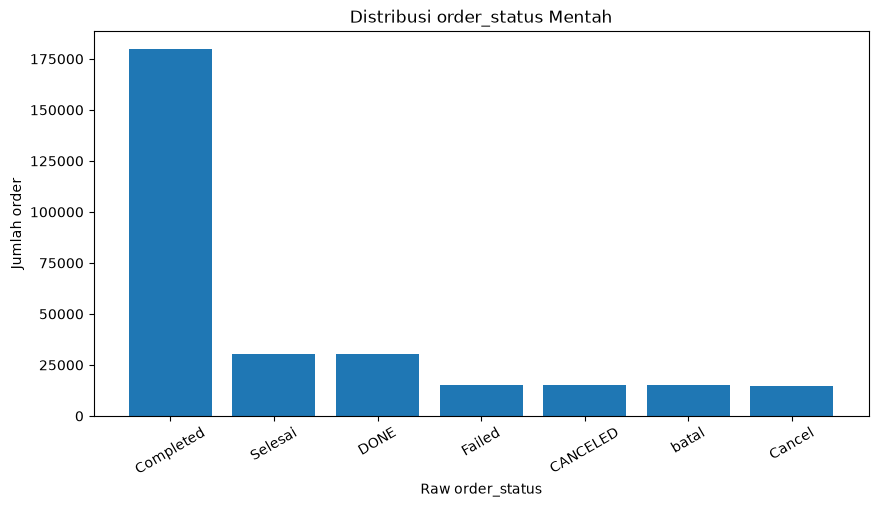

In [58]:
# Visualisasi status mentah
# Kolom order_status memiliki inkonsistensi penulisan dan perlu distandardisasi sebelum dianalisis lebih lanjut.

status_counts = df['order_status'].value_counts()
plt.figure(figsize=(10,5))
plt.bar(status_counts.index, status_counts.values)
plt.title('Distribusi order_status Mentah')
plt.xlabel('Raw order_status')
plt.ylabel('Jumlah order')
plt.xticks(rotation=30)
plt.show()

,count,percentage
cancel_reason,,
Missing,24127,0.402741
Resto Tutup,11920,0.198975
Resto Tidak Ditemukan,11808,0.197106
Driver Terlalu Jauh,6036,0.100756
Menu Habis,6016,0.100422


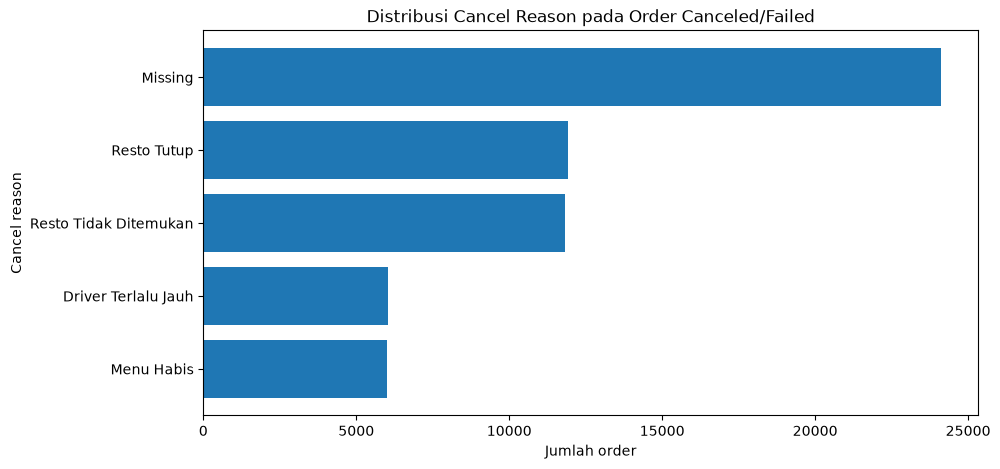

In [59]:
# Distribusi cancel reason untuk order tidak sukses
# untuk mengetahui penyebab/alasan dari transaksi yang tidak berhasil (canceled dan failed)

cancel_reason = df[df['status_clean'].isin(['Canceled','Failed'])]['cancel_reason'].fillna('Missing').value_counts()
display(cancel_reason.to_frame('count').assign(percentage=lambda x: x['count']/x['count'].sum()))

plt.figure(figsize=(10,5))
plt.barh(cancel_reason.index[::-1], cancel_reason.values[::-1])
plt.title('Distribusi Cancel Reason pada Order Canceled/Failed')
plt.xlabel('Jumlah order')
plt.ylabel('Cancel reason')
plt.show()

,category,orders,promo_value,order_share,promo_share
0,Total promo positif,300000,18112488512,1.00000,1.000000
1,Promo outlier >30k,1488,14879998512,0.00496,0.821533
2,Logical error,9603,288090000,0.03201,0.015906
3,Union risk flag,11091,15168088512,0.03697,0.837438


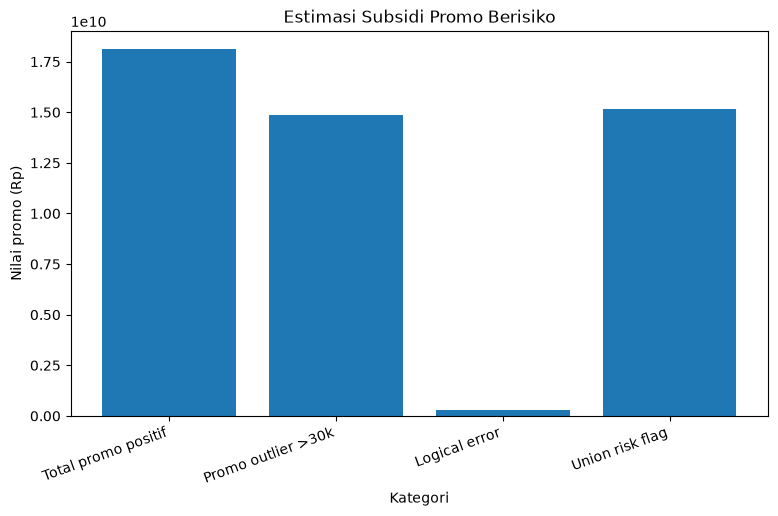

In [60]:
# Estimasi kebocoran promo
# Seberapa besar subsidi yang terekspos pada transaksi mencurigakan dibandingkan keseluruhan subsidi?

promo_total = df['positive_promo'].sum()
promo_outlier = df.loc[df['discount_outlier'], 'positive_promo'].sum()
logical_promo = df.loc[df['logical_error'], 'positive_promo'].sum()
risk_promo = df.loc[df['subsidy_risk_flag'], 'positive_promo'].sum()

promo_summary = pd.DataFrame({
    'category': ['Total promo positif', 'Promo outlier >30k', 'Logical error', 'Union risk flag'],
    'orders': [len(df), df['discount_outlier'].sum(), df['logical_error'].sum(), df['subsidy_risk_flag'].sum()],
    'promo_value': [promo_total, promo_outlier, logical_promo, risk_promo]
})
promo_summary['order_share'] = promo_summary['orders'] / len(df)
promo_summary['promo_share'] = promo_summary['promo_value'] / promo_total
display(promo_summary)

plt.figure(figsize=(9,5))
plt.bar(promo_summary['category'], promo_summary['promo_value'])
plt.title('Estimasi Subsidi Promo Berisiko')
plt.ylabel('Nilai promo (Rp)')
plt.xlabel('Kategori')
plt.xticks(rotation=20, ha='right')
plt.show()

**Insight subsidi:** hanya sebagian kecil order yang ditandai sebagai promo outlier, tetapi nilai subsidinya sangat dominan terhadap total promo positif. Ini menunjukkan masalah bukan pada volume transaksi, melainkan pada nilai promo ekstrem yang lolos validasi.

,metric,value
0,logical_error_orders,9.603000e+03
1,share_of_all_orders,3.201000e-02
2,share_of_completed_orders,3.999700e-02
3,promo_value,2.880900e+08


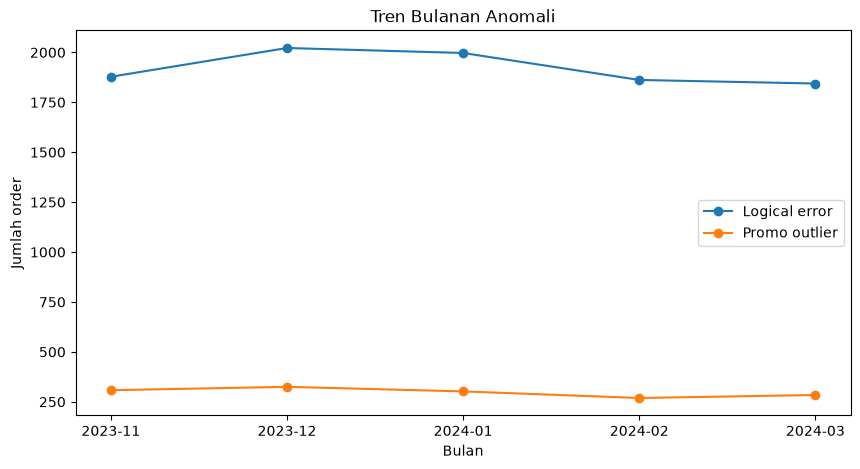

In [61]:
# Logical error completed_time < driver_arrived_time
# mendeteksi kemungkinan bug sistem atau manipulasi transaksi

logical_summary = pd.DataFrame({
    'metric': ['logical_error_orders', 'share_of_all_orders', 'share_of_completed_orders', 'promo_value'],
    'value': [
        df['logical_error'].sum(),
        df['logical_error'].mean(),
        df['logical_error'].sum()/df['is_success'].sum(),
        df.loc[df['logical_error'], 'positive_promo'].sum()
    ]
})
display(logical_summary)

monthly = df.groupby('order_month').agg(
    orders=('order_id','count'),
    logical_error=('logical_error','sum'),
    promo_outlier=('discount_outlier','sum')
).reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly['order_month'], monthly['logical_error'], marker='o', label='Logical error')
plt.plot(monthly['order_month'], monthly['promo_outlier'], marker='o', label='Promo outlier')
plt.title('Tren Bulanan Anomali')
plt.xlabel('Bulan')
plt.ylabel('Jumlah order')
plt.legend()
plt.show()

## 6. Merchant Risk Analysis

Karena tidak tersedia label fraud aktual, pendekatan yang digunakan adalah **risk-based scoring**. Skor dibuat untuk memprioritaskan investigasi, bukan untuk memvonis merchant sebagai fraud.

Komponen risk score:

- `outlier_discount_orders × 5`
- `logical_error_orders × 2`
- `Resto Tidak Ditemukan × 1.5`
- bonus 1 poin jika success ratio berada di persentil 95 ke atas
- bonus 1 poin jika GrabUnlimited ratio berada di persentil 95 ke atas

In [62]:
merchant_agg = df.groupby('merchant_id').agg(
    orders=('order_id','count'),
    success_orders=('is_success','sum'),
    cancel_orders=('is_cancel','sum'),
    failed_orders=('is_failed','sum'),
    unique_users=('user_id','nunique'),
    gu_orders=('is_grab_unlimited','sum'),
    promo_sum=('positive_promo','sum'),
    outlier_discount_orders=('discount_outlier','sum'),
    outlier_subsidy=('positive_promo', lambda s: s[df.loc[s.index,'discount_outlier']].sum()),
    logical_error_orders=('logical_error','sum'),
    logical_error_subsidy=('positive_promo', lambda s: s[df.loc[s.index,'logical_error']].sum()),
    fake_location_cancel=('cancel_reason', lambda s: (s == 'Resto Tidak Ditemukan').sum()),
    missing_cancel_reason=('cancel_reason', lambda s: s.isna().sum()),
    max_user_orders=('user_id', lambda s: s.value_counts().max()),
    top3_user_orders=('user_id', lambda s: s.value_counts().head(3).sum())
).reset_index()

merchant_agg['success_ratio'] = merchant_agg['success_orders'] / merchant_agg['orders']
merchant_agg['gu_ratio'] = merchant_agg['gu_orders'] / merchant_agg['orders']
merchant_agg['top_user_share'] = merchant_agg['max_user_orders'] / merchant_agg['orders']
merchant_agg['top3_user_share'] = merchant_agg['top3_user_orders'] / merchant_agg['orders']
merchant_agg['cancel_missing_rate'] = merchant_agg['missing_cancel_reason'] / (merchant_agg['cancel_orders'] + merchant_agg['failed_orders']).replace(0, np.nan)
merchant_agg = merchant_agg.merge(merchants, on='merchant_id', how='left')

merchant_agg['risk_score'] = (
    merchant_agg['outlier_discount_orders']*5 +
    merchant_agg['logical_error_orders']*2 +
    merchant_agg['fake_location_cancel']*1.5 +
    (merchant_agg['success_ratio'] >= merchant_agg['success_ratio'].quantile(.95)).astype(int)*1 +
    (merchant_agg['gu_ratio'] >= merchant_agg['gu_ratio'].quantile(.95)).astype(int)*1
)

top_risk = merchant_agg.sort_values(['risk_score','outlier_subsidy','logical_error_orders'], ascending=False).head(10)
display(top_risk[['merchant_id','merchant_name','cuisine_type','city','orders','success_ratio','gu_ratio','outlier_discount_orders','outlier_subsidy','logical_error_orders','fake_location_cancel','top3_user_share','risk_score']])

,merchant_id,merchant_name,cuisine_type,city,orders,success_ratio,gu_ratio,outlier_discount_orders,outlier_subsidy,logical_error_orders,fake_location_cancel,top3_user_share,risk_score
6877,GF-06878,Resto GrabMantap 6877,Martabak,Bogor,35,0.714286,0.285714,2,19999998,3,5,0.085714,23.5
360,GF-00361,Resto GrabMantap 360,Beverages,Medan,40,0.750000,0.400000,3,29999997,1,3,0.075000,21.5
1584,GF-01585,Resto GrabMantap 1584,Beverages,Surabaya,46,0.695652,0.369565,2,19999998,2,5,0.065217,21.5
3965,GF-03966,Resto GrabMantap 3965,Seafood,Bekasi,42,0.809524,0.309524,2,19999998,4,2,0.071429,21.0
6353,GF-06354,Resto GrabMantap 6353,Ayam Geprek,Medan,32,0.656250,0.531250,2,19999998,2,4,0.093750,21.0
5167,GF-05168,Resto GrabMantap 5167,Beverages,Medan,42,0.761905,0.333333,3,29999997,2,1,0.071429,20.5
3319,GF-03320,Resto GrabMantap 3319,Beverages,Jakarta,37,0.918919,0.513514,2,19999998,4,1,0.081081,20.5
5501,GF-05502,Resto GrabMantap 5501,Beverages,Makassar,43,0.744186,0.511628,2,19999998,2,4,0.069767,20.0
7133,GF-07134,Resto GrabMantap 7133,Ayam Geprek,Medan,34,0.852941,0.411765,2,19999998,2,4,0.088235,20.0
5277,GF-05278,Resto GrabMantap 5277,Martabak,Tangerang,41,0.829268,0.512195,1,9999999,6,2,0.073171,20.0


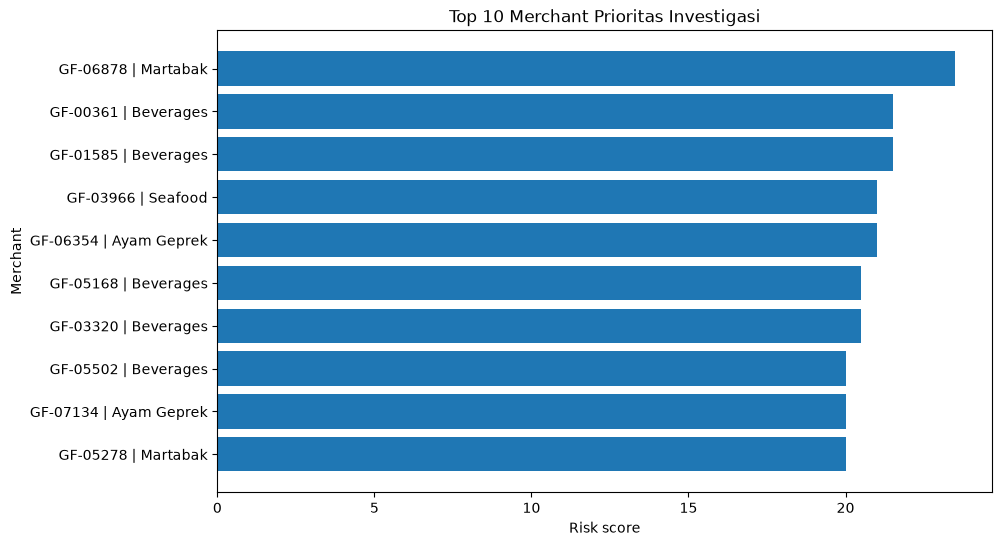

In [63]:
plt.figure(figsize=(10,6))
plot_risk = top_risk.head(10).copy()
plot_risk['label'] = plot_risk['merchant_id'] + ' | ' + plot_risk['cuisine_type']
plt.barh(plot_risk['label'][::-1], plot_risk['risk_score'][::-1])
plt.title('Top 10 Merchant Prioritas Investigasi')
plt.xlabel('Risk score')
plt.ylabel('Merchant')
plt.show()

### Apakah Ada Merchant dengan 2–3 User Dominan?

Pertanyaan ini penting karena modus fraud dapat terlihat dari merchant yang terus-menerus menerima order dari akun yang sama. Namun, pada dataset ini tidak ditemukan pola tersebut.

,metric,value
0,minimum_unique_users_per_merchant,18.000000
1,median_unique_users_per_merchant,37.000000
2,maximum_top3_user_share,0.166667
3,merchant_with_unique_users_<=3,0.000000


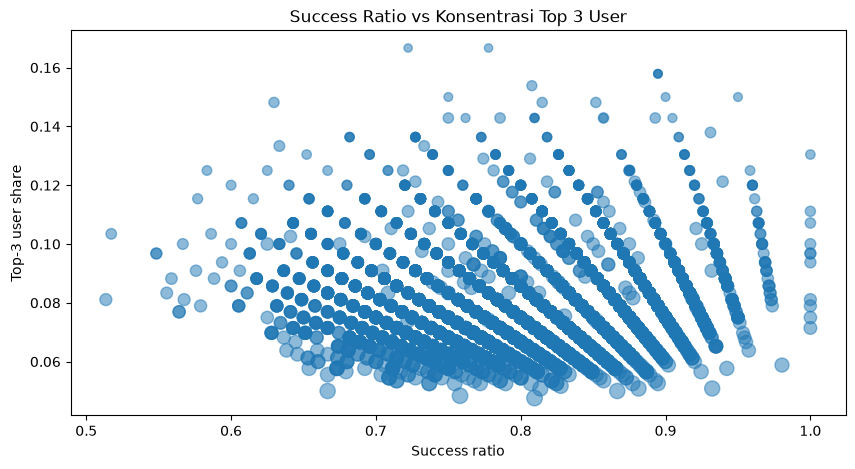

In [64]:
concentration_check = pd.DataFrame({
    'metric': [
        'minimum_unique_users_per_merchant',
        'median_unique_users_per_merchant',
        'maximum_top3_user_share',
        'merchant_with_unique_users_<=3'
    ],
    'value': [
        merchant_agg['unique_users'].min(),
        merchant_agg['unique_users'].median(),
        merchant_agg['top3_user_share'].max(),
        (merchant_agg['unique_users'] <= 3).sum()
    ]
})
display(concentration_check)

plt.figure(figsize=(10,5))
plt.scatter(merchant_agg['success_ratio'], merchant_agg['top3_user_share'], s=merchant_agg['orders']*2, alpha=.5)
plt.title('Success Ratio vs Konsentrasi Top 3 User')
plt.xlabel('Success ratio')
plt.ylabel('Top-3 user share')
plt.show()

**Insight:** pola 2–3 user dominan tidak muncul pada dataset. Oleh karena itu, prioritas investigasi sebaiknya dialihkan ke anomali yang lebih kuat: nilai promo ekstrem, logical error waktu, dan cancel reason “Resto Tidak Ditemukan”.

,merchants,outlier_subsidy,outlier_orders,logical_error_orders,fake_location_cancel
cuisine_type,,,,,
Snacks,1320,2829999717,283,1653,1968
Fast Food,1342,2459999754,246,1544,1991
Seafood,1354,2429999757,243,1695,1995
Ayam Geprek,1388,2409999759,241,1630,1986
Beverages,1270,2389999761,239,1553,1854
Martabak,1326,2359999764,236,1528,2014


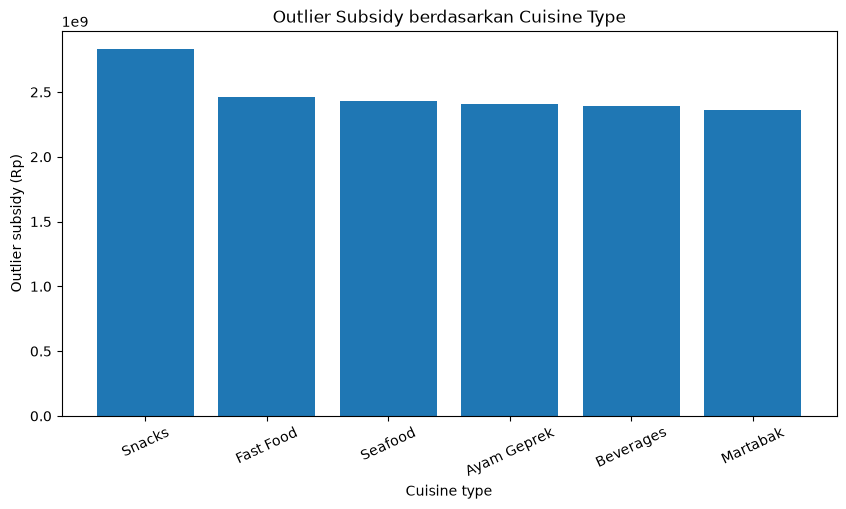

In [65]:
# Risiko berdasarkan cuisine dan city
cuisine_risk = merchant_agg.groupby('cuisine_type').agg(
    merchants=('merchant_id','nunique'),
    outlier_subsidy=('outlier_subsidy','sum'),
    outlier_orders=('outlier_discount_orders','sum'),
    logical_error_orders=('logical_error_orders','sum'),
    fake_location_cancel=('fake_location_cancel','sum')
).sort_values('outlier_subsidy', ascending=False)

display(cuisine_risk)

plt.figure(figsize=(10,5))
plt.bar(cuisine_risk.index, cuisine_risk['outlier_subsidy'])
plt.title('Outlier Subsidy berdasarkan Cuisine Type')
plt.xlabel('Cuisine type')
plt.ylabel('Outlier subsidy (Rp)')
plt.xticks(rotation=25)
plt.show()

## 7. Jawaban Pertanyaan Bisnis

1. **Merchant dengan success ratio tinggi dan hanya 2–3 user:** tidak ditemukan. Minimum unique user per merchant adalah 18, sehingga dataset tidak mendukung hipotesis konsentrasi user ekstrem.
2. **Estimasi subsidi promo berisiko:** Rp15,17 miliar berdasarkan union dari promo outlier dan logical error.
3. **Kualitas status order:** terdapat 7 label status mentah yang perlu distandarisasi menjadi 3 kategori. Sebanyak 30,12% baris memakai label status tidak standar.
4. **Missing cancel reason:** 40,27% order `Canceled`/`Failed` tidak memiliki alasan pembatalan.
5. **Logical error:** terdapat 9.603 order selesai dengan urutan waktu mustahil, setara sekitar 4,00% dari completed order.
6. **Cuisine dan merchant prioritas:** risiko terbesar secara nilai subsidi outlier muncul pada kategori `Snacks`, disusul `Fast Food` dan `Seafood`. Untuk aksi operasional, gunakan daftar top merchant berdasarkan risk score.

## 8. Kesimpulan dan Rekomendasi

### Kesimpulan

Dataset tidak menunjukkan pola fraud berbasis dominasi 2–3 user pada merchant tertentu. Namun, terdapat kebocoran subsidi yang sangat kuat dari **promo outlier**, serta masalah **logical error sistem** dan **cancel reason kosong** yang menghambat investigasi operasional.

### Actionable Recommendation

1. **Merchant Risk Dashboard**  
   Buat dashboard harian top merchant berdasarkan risk score: promo outlier, logical error, dan cancel reason “Resto Tidak Ditemukan”.


2. **Promo Ring-Fencing**  
   Batasi promo per order maksimal Rp30.000 atau wajibkan approval/rule engine untuk promo di atas threshold.


3. **System Patching**  
   Blokir status `Completed` apabila GPS driver belum valid berada dalam radius merchant/customer.


4. **Data Standardization & Driver Protection**  
   - Gunakan dropdown status, dan wajib isi cancel reason, untuk order `Canceled`/`Failed`.
   - Kompensasi cancellation fee untuk driver organik yang terdampak resto tidak ditemukan dengan bukti GPS/log valid.


In [66]:
OUTPUT_DIR = DATA_DIR / 'grab_output'
OUTPUT_DIR.mkdir(exist_ok=True)

# Export dataset hasil cleaning ke file CSV untuk analisis
orders_clean.to_csv(OUTPUT_DIR / 'grab_food_orders_analisis.csv', index=False)

# Export tabel pendukung untuk dashboard/investigasi
merchant_agg.to_csv(OUTPUT_DIR / 'merchant_risk_scoring.csv', index=False)
top_risk.to_csv(OUTPUT_DIR / 'top_risky_merchants.csv', index=False)
promo_summary.to_csv(OUTPUT_DIR / 'promo_risk_summary.csv', index=False)
cuisine_risk.to_csv(OUTPUT_DIR / 'cuisine_risk_summary.csv', index=True)

print('Export complete:', OUTPUT_DIR)

Export complete: dataset_grab\grab_output
